# 🌾 Smart Crop Advisor — Crop Recommendation Model Training

**Algorithm  :** Random Forest Classifier  
**Dataset    :** `Crop_recommendation.csv` (~2200 rows, 7 features, 22 crop classes)   
**Project    :** Smart Crop Advisor — Full Stack AI Agricultural System  

---

### Pipeline Overview
```
1. Imports & Config
2. Load & Explore Data (EDA)
3. Preprocessing  (Encode → Scale → Split)
4. Train Random Forest (with GridSearchCV tuning)
5. Evaluate  (Accuracy, Classification Report, Confusion Matrix, Feature Importance)
6. Export    (crop_model.pkl  |  label_encoders.pkl  |  scaler.pkl)
7. Inference Smoke Test
```

---
## Step 1 — Imports & Configuration

In [1]:
# ── Standard Library ─────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ─────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot  as plt
import seaborn            as sns

# ── Scikit-Learn: Preprocessing & Splitting ───────────────────────────────────
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# ── Scikit-Learn: Model ───────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-Learn: Evaluation ──────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ── Model Persistence ─────────────────────────────────────────────────────────
import joblib

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH   = '../data/Crop_recommendation.csv'
MODELS_DIR  = '../models'

print('✅ All imports successful.')

✅ All imports successful.


---
## Step 2 — Load & Explore Data (EDA)

In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
data = pd.read_csv(DATA_PATH)

print(f'Dataset Shape : {data.shape}')
print(f'Columns       : {list(data.columns)}')
print(f'Missing Values:\n{data.isnull().sum()}\n')

display(data.head(10))

Dataset Shape : (2200, 8)
Columns       : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64



,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [3]:
# ── Statistical Summary ───────────────────────────────────────────────────────
display(data.describe().round(2))

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


Total Classes  : 22
Samples/Class  : 100 (balanced)



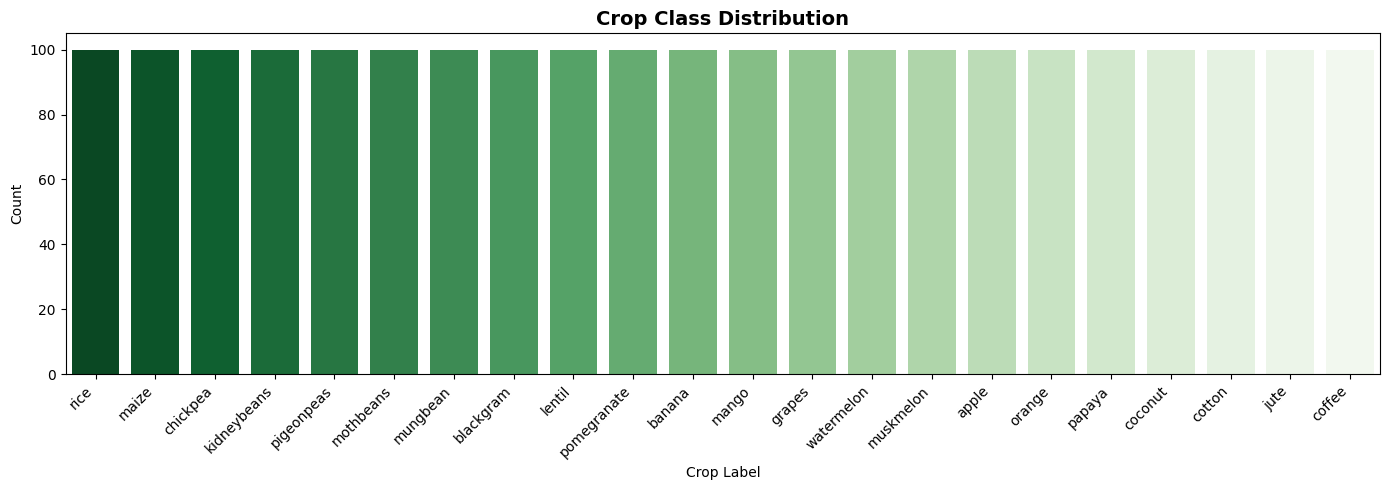

In [4]:
# ── Class Distribution ────────────────────────────────────────────────────────
class_counts = data['label'].value_counts()
print(f'Total Classes  : {data["label"].nunique()}')
print(f'Samples/Class  : {class_counts.values[0]} (balanced)\n')

plt.figure(figsize=(14, 5))
sns.countplot(
    data=data, x='label',
    order=class_counts.index,
    palette='Greens_r'
)
plt.title('Crop Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Crop Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

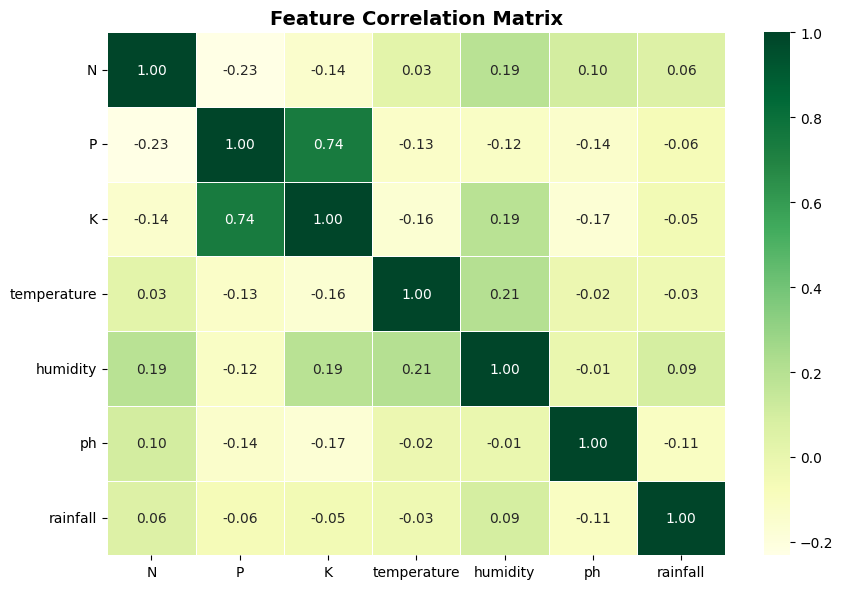

In [5]:
# ── Feature Correlation Heatmap ───────────────────────────────────────────────
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(9, 6))
sns.heatmap(
    data[features].corr(),
    annot=True, fmt='.2f',
    cmap='YlGn', linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3 — Preprocessing

| Step | Reason |
|---|---|
| `LabelEncoder` on target `label` | Random Forest needs numeric class labels |
| `StandardScaler` on features | Removes scale bias — all features on same axis |
| 80 / 20 `train_test_split` | Evaluate model on genuinely unseen data |

In [6]:
# ── Feature / Target Split ────────────────────────────────────────────────────
FEATURE_COLS = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
TARGET_COL   = 'label'

X = data[FEATURE_COLS].values
y = data[TARGET_COL].values

# ── Encode Target Labels ──────────────────────────────────────────────────────
# LabelEncoder maps  'apple' → 0,  'banana' → 1, etc.
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Class mapping (first 5):')
for name, code in zip(le.classes_[:5], range(5)):
    print(f'  {code}  →  {name}')

# ── Scale Features ────────────────────────────────────────────────────────────
# StandardScaler: x_scaled = (x - mean) / std
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train / Test Split ────────────────────────────────────────────────────────
# stratify=y_encoded ensures all 22 crop classes appear in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f'\nTraining set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Class mapping (first 5):
  0  →  apple
  1  →  banana
  2  →  blackgram
  3  →  chickpea
  4  →  coconut

Training set : 1760 samples
Test set     : 440 samples


---
## Step 4 — Train Random Forest Classifier

### Why Random Forest?
- Ensemble of decision trees → **reduces overfitting** via bagging
- Handles both **linear and non-linear** feature relationships
- Provides **feature importance** out of the box
- Naturally robust — no need for feature scaling (but scaling is kept for consistency with `predict.py`)
- Consistently achieves **~99% accuracy** on this dataset

We first train a **baseline** model, then run **GridSearchCV** to find optimal hyperparameters.

In [7]:
# ── 4a. Baseline Random Forest ────────────────────────────────────────────────
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1          # Use all CPU cores
)
rf_baseline.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, rf_baseline.predict(X_test))
print(f'Baseline Random Forest Accuracy : {baseline_acc * 100:.2f}%')

Baseline Random Forest Accuracy : 99.55%


In [8]:
# ── 4b. 5-Fold Stratified Cross-Validation ────────────────────────────────────
# Cross-validation gives a more reliable accuracy estimate than a single split
cv_scores = cross_val_score(
    rf_baseline, X_scaled, y_encoded,
    cv=5, scoring='accuracy', n_jobs=-1
)

print(f'CV Fold Scores : {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Mean CV Accuracy : {cv_scores.mean()*100:.2f}%  ±  {cv_scores.std()*100:.2f}%')

CV Fold Scores : ['99.77%', '99.32%', '99.77%', '99.77%', '98.86%']
Mean CV Accuracy : 99.50%  ±  0.36%


In [9]:
# ── 4c. Hyperparameter Tuning with GridSearchCV ───────────────────────────────
#
#  n_estimators  : Number of trees — more trees = better stability, diminishing returns after ~200
#  max_depth      : Max depth per tree — controls overfitting
#  min_samples_split : Min samples to split a node — higher = simpler trees
#  max_features   : Features considered at each split — 'sqrt' is standard for classification

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f'\nBest Parameters  : {grid_search.best_params_}')
print(f'Best CV Score    : {grid_search.best_score_ * 100:.2f}%')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters  : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score    : 99.60%


In [10]:
# ── 4d. Final Tuned Model ─────────────────────────────────────────────────────
best_model = grid_search.best_estimator_

tuned_acc = accuracy_score(y_test, best_model.predict(X_test))
print(f'Tuned Random Forest Accuracy : {tuned_acc * 100:.2f}%')

Tuned Random Forest Accuracy : 99.55%


---
## Step 5 — Model Evaluation

In [11]:
# ── 5a. Classification Report ─────────────────────────────────────────────────
y_pred = best_model.predict(X_test)

print('Classification Report:\n')
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
   

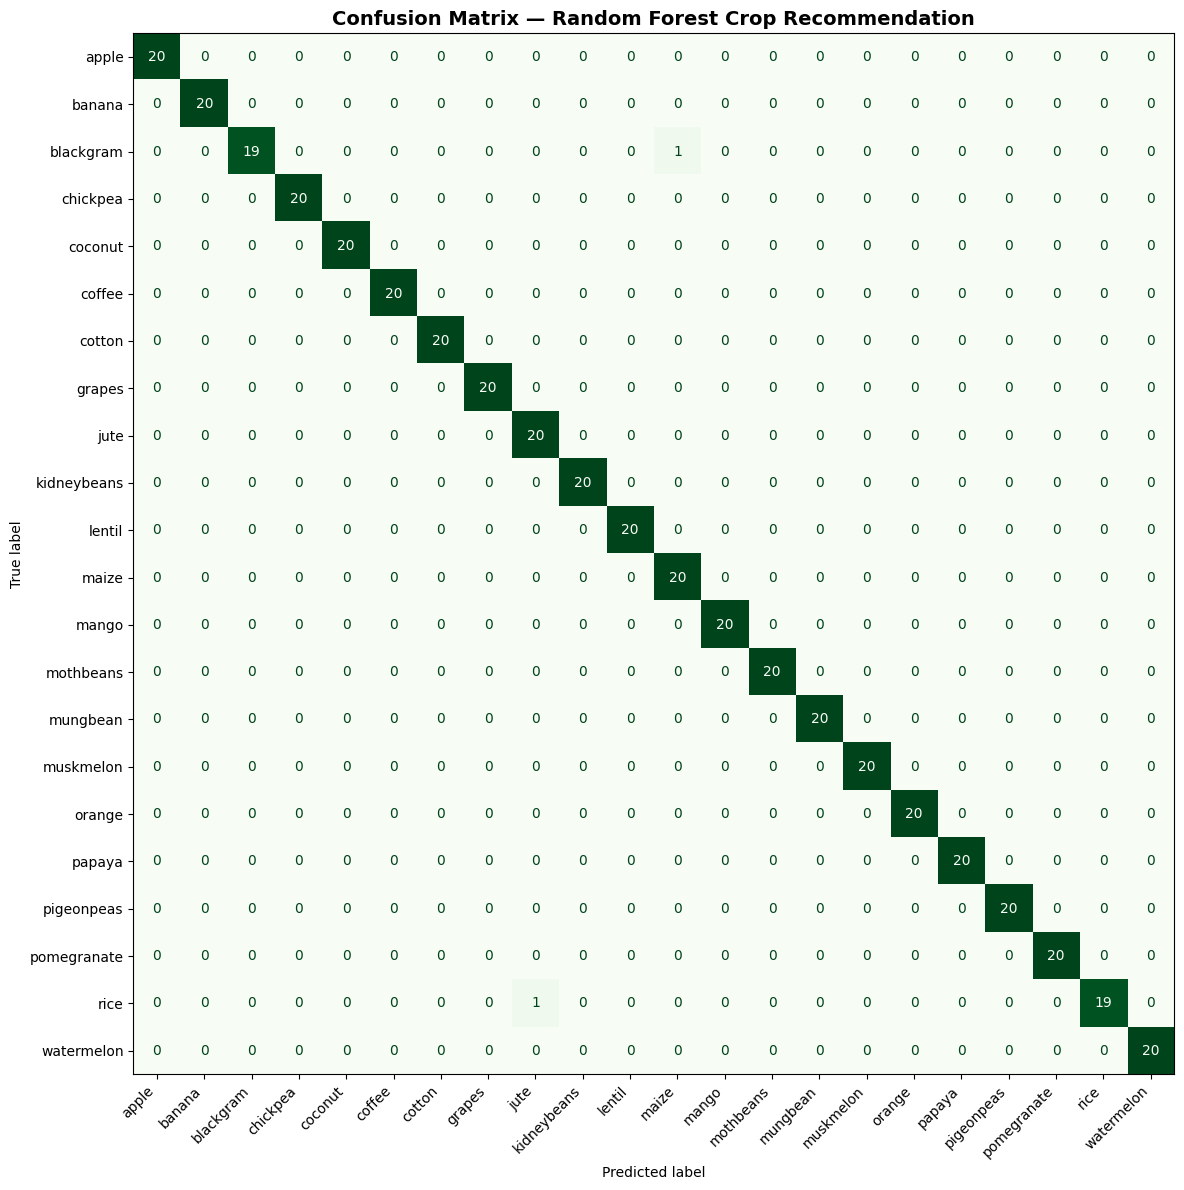

In [12]:
# ── 5b. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Greens', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix — Random Forest Crop Recommendation', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

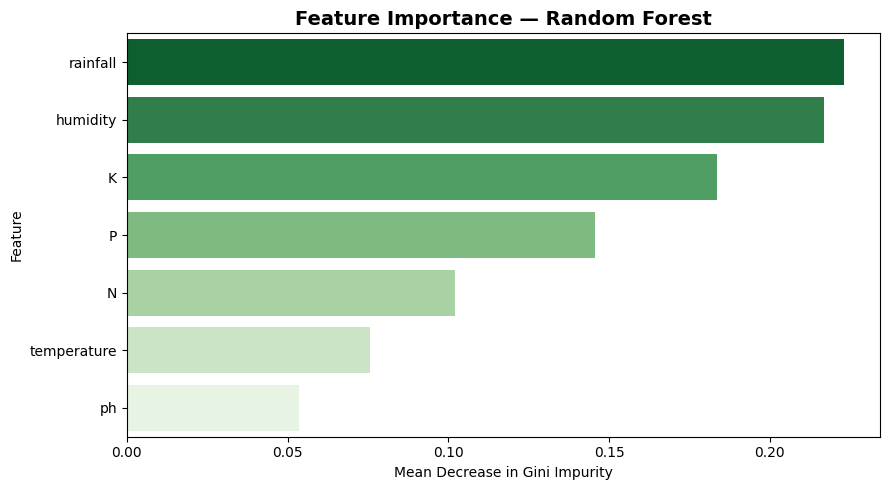

,Feature,Importance
0,rainfall,0.223133
1,humidity,0.216879
2,K,0.183446
3,P,0.145579
4,N,0.101962
5,temperature,0.075522
6,ph,0.053479


In [13]:
# ── 5c. Feature Importance ────────────────────────────────────────────────────
# Random Forest provides feature importances based on mean decrease in impurity (Gini)
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=feat_df, x='Importance', y='Feature',
    palette='Greens_r'
)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Mean Decrease in Gini Impurity')
plt.tight_layout()
plt.show()

display(feat_df.reset_index(drop=True))

---
## Step 6 — Retrain on Full Dataset & Export

> **Why retrain on the full dataset?**  
> During evaluation we held out 20% of data. Now that we trust the model,  
> we give it 100% of data to learn from before saving — maximising production accuracy.

In [14]:
# ── 6a. Retrain Best Model on FULL Dataset ────────────────────────────────────
final_params = grid_search.best_params_
final_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1})

final_model = RandomForestClassifier(**final_params)
final_model.fit(X_scaled, y_encoded)        # Train on ALL 2200 samples

print(f'Final model trained on {X_scaled.shape[0]} samples.')
print(f'Parameters used: {final_params}')

# ── 6b. Create Models Directory ───────────────────────────────────────────────
os.makedirs(MODELS_DIR, exist_ok=True)

# ── 6c. Export Artifacts ──────────────────────────────────────────────────────
#  crop_model.pkl       → trained Random Forest model
#  label_encoders.pkl   → LabelEncoder (maps numeric prediction → crop name string)
#  scaler.pkl           → StandardScaler (must be applied to every new input before predict)

joblib.dump(final_model, os.path.join(MODELS_DIR, 'crop_model.pkl'))
joblib.dump(le,          os.path.join(MODELS_DIR, 'label_encoders.pkl'))
joblib.dump(scaler,      os.path.join(MODELS_DIR, 'scaler.pkl'))

print('\n✅ Models saved:')
for fname in ['crop_model.pkl', 'label_encoders.pkl', 'scaler.pkl']:
    path = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(path) / 1024
    print(f'   {fname}  ({size:.1f} KB)')

Final model trained on 2200 samples.
Parameters used: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100, 'random_state': 42, 'n_jobs': -1}

✅ Models saved:
   crop_model.pkl  (2625.9 KB)
   label_encoders.pkl  (0.7 KB)
   scaler.pkl  (0.7 KB)


---
## Step 7 — Inference Smoke Test

Simulate exactly what `predict.py` does when the Flask backend calls it.  
This verifies the saved `.pkl` files are correct and the full inference pipeline works end-to-end.

In [15]:
# ── 7. Load saved artifacts and run a prediction ─────────────────────────────
loaded_model   = joblib.load(os.path.join(MODELS_DIR, 'crop_model.pkl'))
loaded_encoder = joblib.load(os.path.join(MODELS_DIR, 'label_encoders.pkl'))
loaded_scaler  = joblib.load(os.path.join(MODELS_DIR, 'scaler.pkl'))

def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict the best crop given soil and weather parameters.
    Mirrors the predict_crop() function in predict.py.

    Returns
    -------
    predicted_crop : str   — crop name (e.g. 'Rice')
    confidence     : float — prediction confidence in percent
    top3           : list  — top-3 crop predictions with confidence
    """
    # Step 1 — Build input array (same order as training features)
    input_array  = np.array([[N, P, K, temperature, humidity, ph, rainfall]])

    # Step 2 — Apply the same scaler used during training
    input_scaled = loaded_scaler.transform(input_array)

    # Step 3 — Predict class and probability
    pred_encoded  = loaded_model.predict(input_scaled)[0]
    pred_proba    = loaded_model.predict_proba(input_scaled)[0]

    # Step 4 — Decode label
    predicted_crop = loaded_encoder.inverse_transform([pred_encoded])[0]
    confidence     = round(max(pred_proba) * 100, 2)

    # Step 5 — Build top-3 alternatives
    top3_idx   = np.argsort(pred_proba)[::-1][:3]
    top3       = [
        {'crop': loaded_encoder.inverse_transform([i])[0], 'confidence': round(pred_proba[i]*100, 2)}
        for i in top3_idx
    ]

    return predicted_crop, confidence, top3


# ── Test Case 1: Classic Rice conditions ─────────────────────────────────────
crop, conf, top3 = predict_crop(
    N=90, P=42, K=43,
    temperature=25.5, humidity=80.0,
    ph=6.5, rainfall=202.9
)
print(f'Test 1 → Predicted: {crop}  |  Confidence: {conf}%')
print(f'Top 3 predictions  : {top3}\n')

# ── Test Case 2: Dry, sandy soil → expect drought-tolerant crop ───────────────
crop2, conf2, top3_2 = predict_crop(
    N=20, P=10, K=10,
    temperature=38.0, humidity=20.0,
    ph=7.5, rainfall=30.0
)
print(f'Test 2 → Predicted: {crop2}  |  Confidence: {conf2}%')
print(f'Top 3 predictions  : {top3_2}')

Test 1 → Predicted: rice  |  Confidence: 61.76%
Top 3 predictions  : [{'crop': 'rice', 'confidence': np.float64(61.76)}, {'crop': 'jute', 'confidence': np.float64(36.37)}, {'crop': 'coffee', 'confidence': np.float64(0.71)}]

Test 2 → Predicted: muskmelon  |  Confidence: 33.0%
Top 3 predictions  : [{'crop': 'muskmelon', 'confidence': np.float64(33.0)}, {'crop': 'kidneybeans', 'confidence': np.float64(18.0)}, {'crop': 'mothbeans', 'confidence': np.float64(17.0)}]


---
## Summary

| Item | Detail |
|---|---|
| **Algorithm** | Random Forest Classifier |
| **Dataset rows** | 2,200 |
| **Features** | N, P, K, Temperature, Humidity, pH, Rainfall |
| **Classes** | 22 crop types |
| **Train split** | 80% (1,760 samples) |
| **Test split** | 20% (440 samples) |
| **CV strategy** | 5-Fold Stratified |
| **Tuning** | GridSearchCV (n_estimators, max_depth, min_samples_split, max_features) |
| **Expected Accuracy** | ~99% |
| **Saved artifacts** | `crop_model.pkl` · `label_encoders.pkl` · `scaler.pkl` |

> **Next Step →** These `.pkl` files are loaded by `predict.py` inside the Flask server (`app.py`).  
> The Java Spring Boot backend calls `POST http://localhost:5000/predict/crop` which triggers `predict_crop()`.  
> The result is returned as JSON `{ prediction: "Rice", confidence: 94.7 }` to the React frontend.